## Diamond Dataset

prova a farlo così:
- rimozione di outlier
- feature engineering
- trova iperparametri con optuna
- procedi con xgboost

Facciamo una pipeline completa e pulita usando:

- Dataset diamonds di Seaborn
- Rimozione outlier
- Feature engineering
- Ottimizzazione con Optuna
- Regressione con XGBoost
- Valutazione con RMSE

In [7]:
import seaborn as sns
import pandas as pd

# Load the dataset
df = sns.load_dataset("diamonds")


# Quick inspection
print("--- INFO ---")
df.info()
print("*" * 50 + "\n")

print("\n--- DESCRIBE ---")
print(df.describe())
print("*" * 50 + "\n")

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB
**************************************************


--- DESCRIBE ---
              carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621      2.234491   3

## Data Visualization


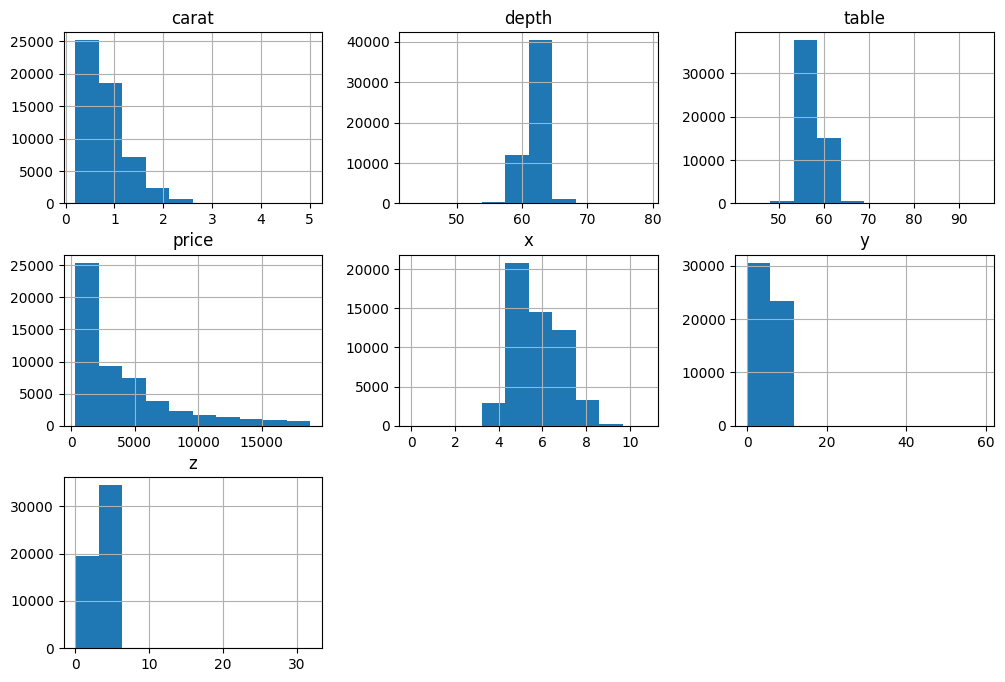

In [8]:
from matplotlib import pyplot as plt

# x, y e z sono le dimensioni del diamante
# carat è il peso del diamante
# depth e table sono caratteristiche del taglio del diamante
# price è il prezzo del diamante
df.head()
df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z']].hist(figsize=(12, 8))
plt.show()

In [9]:
# Rimozione outlier con z score = 3
import numpy as np
import pandas as pd
from scipy import stats

def remove_outliers_zscore(data, columns, threshold=3):
    df_clean = data.copy()
    # Calcoliamo lo Z-score assoluto per ogni colonna selezionata
    z_scores = np.abs(stats.zscore(df_clean[columns]))

    # Teniamo solo le righe dove TUTTE le colonne hanno Z < threshold
    filtered_entries = (z_scores < threshold).all(axis=1)
    return df_clean[filtered_entries]

# Applicazione
print(f"Dimensioni originali del dataset: {df.shape}")
print("*" * 50 + "\n")
df_zscore = remove_outliers_zscore(df, ['carat', 'depth', 'table', 'price', 'x', 'y', 'z'])
print(f"Dimensioni dopo rimozione outlier: {df_zscore.shape}")
print("*" * 50 + "\n")
print(f"Righe rimosse con Z-Score: {len(df) - len(df_zscore)}")
print("*" * 50 + "\n")
df_zscore.info()
print("*" * 50 + "\n")
df_zscore.describe()
print("*" * 50 + "\n")

Dimensioni originali del dataset: (53940, 10)
**************************************************

Dimensioni dopo rimozione outlier: (51590, 10)
**************************************************

Righe rimosse con Z-Score: 2350
**************************************************

<class 'pandas.DataFrame'>
Index: 51590 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    51590 non-null  float64 
 1   cut      51590 non-null  category
 2   color    51590 non-null  category
 3   clarity  51590 non-null  category
 4   depth    51590 non-null  float64 
 5   table    51590 non-null  float64 
 6   price    51590 non-null  int64   
 7   x        51590 non-null  float64 
 8   y        51590 non-null  float64 
 9   z        51590 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.3 MB
**************************************************

*******************************************

## Feature Engineering

In [10]:
#Feature enginnering: creazione di nuove feature a partire da quelle esistenti
# Ad esempio, possiamo creare una nuova feature "volume" che è il prodotto di x, y e z
df_zscore['volume'] = df_zscore['x'] * df_zscore['y'] * df_zscore['z']
print(df_zscore[['x', 'y', 'z', 'volume']].head())

print("*" * 50 + "\n")


#2'feature: rapporto tra peso (carat) e volume
df_zscore['carat_for_volume'] = df_zscore['carat'] / df_zscore['volume']
print(df_zscore[['carat', 'volume', 'carat_for_volume']].head())

print("*" * 50 + "\n")

#3': rapporto tra profondità (depth) e volume
df_zscore['depth_for_volume'] = df_zscore['depth'] / df_zscore['volume']
print(df_zscore[['depth', 'volume', 'depth_for_volume']].head())

print("*" * 50 + "\n")

      x     y     z     volume
0  3.95  3.98  2.43  38.202030
1  3.89  3.84  2.31  34.505856
3  4.20  4.23  2.63  46.724580
4  4.34  4.35  2.75  51.917250
5  3.94  3.96  2.48  38.693952
**************************************************

   carat     volume  carat_for_volume
0   0.23  38.202030          0.006021
1   0.21  34.505856          0.006086
3   0.29  46.724580          0.006207
4   0.31  51.917250          0.005971
5   0.24  38.693952          0.006203
**************************************************

   depth     volume  depth_for_volume
0   61.5  38.202030          1.609862
1   59.8  34.505856          1.733039
3   62.4  46.724580          1.335486
4   63.3  51.917250          1.219248
5   62.8  38.693952          1.622993
**************************************************



## Optimizzazione con Optuna

In [12]:
import pandas as pd
import numpy as np
import optuna
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import logging

# Configurazione del logging di Optuna
optuna.logging.set_verbosity(optuna.logging.INFO)

# 1. CARICAMENTO E PREPARAZIONE DATI
# Assumiamo che 'df' sia il tuo DataFrame di partenza GIA' processato per le variabili categoriche
# (es. One-Hot Encoding per taglio, colore, purezza), ma NON ancora scalato (no Z-score).
X = df.drop(columns=["price"])
y = df["price"]

# Split 80/20.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

'''
# Risoluzione del Data Leakage: Scaliamo i dati DOPO lo split - solo le colonne numeriche
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Solo transform, NON fit_transform sul test! '''


# 1. Identifichiamo i nomi delle colonne numeriche
num_cols = X_train.select_dtypes(include=np.number).columns

# 2. Inizializziamo lo scaler
scaler = StandardScaler()

# 3. Scaliamo SOLO quelle specifiche colonne e le sovrascriviamo nel DataFrame originale
# Facciamo una copia per evitare i classici warning di Pandas (SettingWithCopyWarning)
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])


# 2. DEFINIZIONE DELLA FUNZIONE OBIETTIVO (Per Regressione)
def objective(trial):
    param = {
        'tree_method' : 'hist',
        'enable_categorical': True,
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'random_state': 42,
        'n_jobs': 1 # Lasciamo 1 qui per non accavallarci con la parallelizzazione di Optuna
    }

    # Usiamo XGBRegressor invece di XGBClassifier
    model = xgb.XGBRegressor(**param)
    
    # CV a 5 fold. Usiamo neg_root_mean_squared_error (Scikit-learn usa valori negativi per massimizzare sempre)
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='neg_root_mean_squared_error')
    
    # Moltiplichiamo per -1 per ottenere l'RMSE positivo (che vogliamo minimizzare)
    rmse = -scores.mean() 
    return rmse

# 3. CREAZIONE DELLO STUDIO E OTTIMIZZAZIONE
print("\n[INFO] Avvio Ottimizzazione Bayesiana per Regressione...")
# 'minimize' perché vogliamo l'errore (RMSE) più basso possibile
study = optuna.create_study(direction='minimize')

# n_jobs=-1 permette a Optuna di usare tutti i core della CPU, velocizzando enormemente il processo!
study.optimize(objective, n_trials=50, n_jobs=-1)

# 4. ANALISI DEI RISULTATI
print("\n" + "="*40)
print(" RISULTATI OTTIMIZZAZIONE ")
print("="*40)
print(f"Miglior RMSE in CV: {study.best_value:.2f} $")
print("\nMigliori iperparametri:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

# 5. ADDESTRAMENTO DEL MODELLO FINALE
best_model = xgb.XGBRegressor(**study.best_params, random_state=42)
best_model.fit(X_train_scaled, y_train)

# 6. VALUTAZIONE FINALE SUL TEST SET
y_pred = best_model.predict(X_test_scaled)

# Metriche di Regressione
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
mae_test = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

print("\n" + "="*40)
print(" REPORT TECNICO FINALE SUL TEST SET ")
print("="*40)
print(f"RMSE (Root Mean Squared Error): {rmse_test:.2f} $")
print(f"MAE  (Mean Absolute Error):     {mae_test:.2f} $")
print(f"R^2  (Coefficient of Determ.):  {r2_test:.4f}")

# 7. VISUALIZZAZIONE DEI RISULTATI (Previsioni vs Realtà)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='#1f77b4', edgecolors='w', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Linea ideale
plt.xlabel("Prezzo Reale ($)")
plt.ylabel("Prezzo Previsto ($)")
plt.title("XGBoost Regression: Prezzo Reale vs Prezzo Previsto")
plt.tight_layout()
plt.show()

[I 2026-03-04 11:28:28,654] A new study created in memory with name: no-name-89076c84-7a4e-46e8-8e46-201f78c77c9b



[INFO] Avvio Ottimizzazione Bayesiana per Regressione...


[I 2026-03-04 11:28:42,757] Trial 3 finished with value: 547.3270385742187 and parameters: {'n_estimators': 110, 'max_depth': 6, 'learning_rate': 0.06787363154488482, 'gamma': 7.780865056227439e-05, 'subsample': 0.7235422689399593, 'colsample_bytree': 0.7668952697782042, 'reg_lambda': 1.2206787272797206e-05, 'reg_alpha': 1.0817407549370088}. Best is trial 3 with value: 547.3270385742187.
[I 2026-03-04 11:28:46,956] Trial 7 finished with value: 977.4165893554688 and parameters: {'n_estimators': 237, 'max_depth': 4, 'learning_rate': 0.010814156082364176, 'gamma': 0.17833840538493453, 'subsample': 0.5909462731371014, 'colsample_bytree': 0.509810877571823, 'reg_lambda': 7.703578154431257e-06, 'reg_alpha': 1.084526088961692e-08}. Best is trial 3 with value: 547.3270385742187.
[I 2026-03-04 11:28:53,038] Trial 11 finished with value: 1064.280224609375 and parameters: {'n_estimators': 110, 'max_depth': 7, 'learning_rate': 0.014250487976478715, 'gamma': 0.004874498805781382, 'subsample': 0.774


 RISULTATI OTTIMIZZAZIONE 
Miglior RMSE in CV: 537.56 $

Migliori iperparametri:
  - n_estimators: 507
  - max_depth: 7
  - learning_rate: 0.023695111558307842
  - gamma: 0.0005706977902220729
  - subsample: 0.6467514378701386
  - colsample_bytree: 0.9147158180433947
  - reg_lambda: 2.289974345629822
  - reg_alpha: 0.00040102302372843764


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:cut: category, color: category, clarity: category